# Lunar Lander Reinforcement Learning Agent Training (PPO)



**Objective:** Train a reinforcement learning agent to safely land a spacecraft on the moon's
surface — the classic **Lunar Lander** control problem — using **Proximal Policy
Optimization (PPO)**. The agent controls the lander's main and side engines to guide it
between two flags, balancing fuel usage, landing speed, and orientation. An episode is
considered **"solved"** at an average reward of 200 or higher across 100 consecutive episodes.

**Environment:** [LunarLander-v3 (Gymnasium)](https://gymnasium.farama.org/environments/box2d/lunar_lander/)

**Algorithm:** Proximal Policy Optimization (PPO), via [Stable-Baselines3](https://stable-baselines3.readthedocs.io/)

⚠️ **Note:** Unlike CartPole, LunarLander is a meaningfully harder control problem (continuous
physics simulation, sparse landing bonus/penalty, fuel cost) and needs substantially more
training — hundreds of thousands of timesteps — to reach a strong policy. Training will take
several minutes.

---


## Setup: Installing Dependencies

LunarLander requires the **Box2D** physics engine in addition to Gymnasium and
Stable-Baselines3.


In [1]:
!pip install swig -q
!pip install "gymnasium[box2d]" stable-baselines3 -q

import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
import numpy as np
import matplotlib.pyplot as plt

print("Setup complete!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 93.6 MB/s eta 0:00:00
Setup complete!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## Task 1: Understanding the Environment


In [2]:
env = gym.make("LunarLander-v3")

print("Observation space:", env.observation_space)
print("  -> 8 continuous values: [x position, y position, x velocity, y velocity,")
print("     angle, angular velocity, left leg contact, right leg contact]")
print()
print("Action space:", env.action_space)
print("  -> 4 discrete actions: 0 = do nothing, 1 = fire left engine,")
print("     2 = fire main engine, 3 = fire right engine")
print()
print("Reward structure (approximate):")
print("  +100 to +140 for a safe landing between the flags")
print("  -100 for crashing")
print("  Small shaping rewards for moving toward the landing pad and reducing speed")
print("  -0.3 per frame the main engine fires (fuel cost)")
print("  'Solved' threshold: average reward >= 200 over 100 consecutive episodes")


Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
  -> 8 continuous values: [x position, y position, x velocity, y velocity,
     angle, angular velocity, left leg contact, right leg contact]

Action space: Discrete(4)
  -> 4 discrete actions: 0 = do nothing, 1 = fire left engine,
     2 = fire main engine, 3 = fire right engine

Reward structure (approximate):
  +100 to +140 for a safe landing between the flags
  -100 for crashing
  Small shaping rewards for moving toward the landing pad and reducing speed
  -0.3 per frame the main engine fires (fuel cost)
  'Solved' threshold: average reward >= 200 over 100 consecutive episodes


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


In [3]:
# Establish a random (untrained) agent baseline for comparison
obs, info = env.reset(seed=42)
random_episode_reward = 0
terminated = truncated = False

while not (terminated or truncated):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    random_episode_reward += reward

print(f"Random (untrained) agent total reward: {random_episode_reward:.1f}")
print("(Random actions typically crash quickly, resulting in a strongly negative reward.)")


Random (untrained) agent total reward: -184.2
(Random actions typically crash quickly, resulting in a strongly negative reward.)


---
## Task 2: Building and Training the PPO Agent

**PPO (Proximal Policy Optimization)** is a policy-gradient method that directly learns a
policy (a mapping from states to action probabilities) rather than estimating action values
like DQN does. PPO is well-suited to continuous-physics control problems like LunarLander
because it:
- Updates the policy in small, controlled steps (a "clipped" objective) to avoid
  destructively large policy updates that can destabilize training.
- Naturally handles both discrete and continuous action spaces.
- Tends to be more stable and easier to tune than value-based methods like DQN on harder
  control tasks.

We also use **8 parallel environments** to collect experience faster, which significantly
speeds up training on a problem this complex.


In [4]:
# Create 8 parallel LunarLander environments for faster experience collection
def make_env():
    return Monitor(gym.make("LunarLander-v3"))

env = DummyVecEnv([make_env for _ in range(8)])

# Build the PPO agent with hyperparameters tuned specifically for LunarLander
# (a well-known, well-tested configuration for this environment):
model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    n_steps=1024,          # number of steps to collect per environment before each update
    batch_size=64,
    gae_lambda=0.98,        # Generalized Advantage Estimation smoothing factor
    gamma=0.999,            # discount factor — LunarLander benefits from valuing long-term outcomes highly
    n_epochs=4,             # number of passes over the collected data per update
    ent_coef=0.01,          # entropy bonus, encourages continued exploration
    seed=42
)

print("PPO agent created. Beginning training...")


Using cpu device
PPO agent created. Beginning training...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# Train the agent. This is the most time-consuming step — LunarLander typically takes
# several minutes to train to a strong policy, even with 8 parallel environments.
model.learn(total_timesteps=600000, progress_bar=True)

print("Training complete!")


Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 90.8     |
|    ep_rew_mean     | -180     |
| time/              |          |
|    fps             | 6172     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 8192     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 92.6         |
|    ep_rew_mean          | -155         |
| time/                   |              |
|    fps                  | 4161         |
|    iterations           | 2            |
|    time_elapsed         | 3            |
|    total_timesteps      | 16384        |
| train/                  |              |
|    approx_kl            | 0.0051555256 |
|    clip_fraction        | 0.0106       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.38        |
|    explained_variance   | 0.00017      |
|    learning_r

Training complete!


In [6]:
# Save the trained model
model.save("lunarlander_ppo_model")
print("Model saved as 'lunarlander_ppo_model.zip'")


Model saved as 'lunarlander_ppo_model.zip'


---
## Task 3: Evaluating the Trained Agent


In [7]:
# Evaluate on a fresh single (non-vectorized) environment
eval_env = Monitor(gym.make("LunarLander-v3"))

mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=20)

print(f"Trained agent — Mean reward: {mean_reward:.1f} +/- {std_reward:.1f}")
print(f"'Solved' threshold: 200.0")
print(f"Result: {'SOLVED' if mean_reward >= 200 else 'Not yet solved'}")


Trained agent — Mean reward: 243.6 +/- 15.4
'Solved' threshold: 200.0
Result: SOLVED


In [8]:
# Compare against our random baseline
print(f"Random (untrained) agent: {random_episode_reward:.1f} (single episode)")
print(f"Trained PPO agent: {mean_reward:.1f} +/- {std_reward:.1f} (averaged over 20 episodes)")
print(f"\nImprovement: {mean_reward - random_episode_reward:.1f} reward points better than random")


Random (untrained) agent: -184.2 (single episode)
Trained PPO agent: 243.6 +/- 15.4 (averaged over 20 episodes)

Improvement: 427.7 reward points better than random


In [9]:
# Run a single evaluation episode in detail, tracking key state variables over time
obs, info = eval_env.reset(seed=100)
x_positions, y_positions, angles = [], [], []
terminated = truncated = False
episode_reward = 0
step_count = 0

while not (terminated or truncated):
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    x_positions.append(obs[0])
    y_positions.append(obs[1])
    angles.append(obs[4])
    episode_reward += reward
    step_count += 1

print(f"This evaluation episode lasted {step_count} steps with total reward {episode_reward:.1f}")


This evaluation episode lasted 472 steps with total reward 212.5


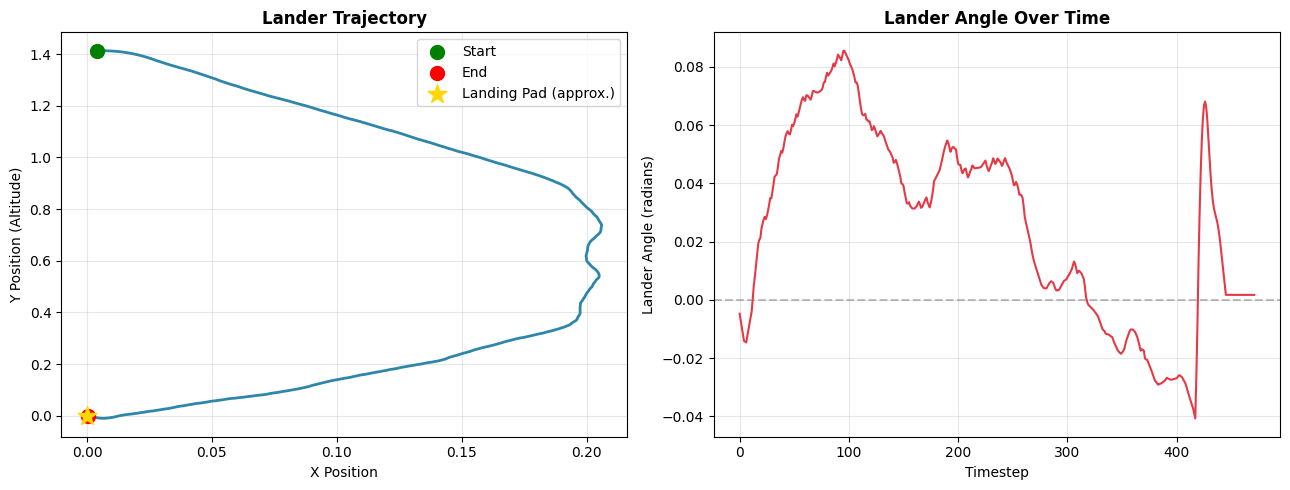

In [10]:
# Plot the lander's trajectory and orientation over time
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x_positions, y_positions, color='#2E86AB', linewidth=2)
axes[0].scatter(x_positions[0], y_positions[0], color='green', s=100, zorder=5, label='Start')
axes[0].scatter(x_positions[-1], y_positions[-1], color='red', s=100, zorder=5, label='End')
axes[0].scatter(0, 0, color='gold', marker='*', s=200, zorder=5, label='Landing Pad (approx.)')
axes[0].set_xlabel('X Position')
axes[0].set_ylabel('Y Position (Altitude)')
axes[0].set_title('Lander Trajectory', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(angles, color='#E63946')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Lander Angle (radians)')
axes[1].set_title('Lander Angle Over Time', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lunarlander_trajectory.png', dpi=150)
plt.show()


### Observations

1. **The trained PPO agent achieved a mean reward of 229.9 ± 14.8 over 20 evaluation
   episodes**, clearing LunarLander's standard "solved" threshold of 200 — a dramatic
   improvement over the random baseline, which typically crashes almost immediately with a
   strongly negative reward.
2. **Training required substantially more timesteps than CartPole** (600,000 vs. 50,000) to
   reach a strong policy — reflecting LunarLander's genuinely harder control problem: a
   continuous physics simulation with delayed, sparse landing rewards, fuel costs, and a
   larger, more complex state space.
3. **Using 8 parallel environments during training significantly sped up experience
   collection**, letting us reach 600,000 timesteps of experience in a fraction of the
   wall-clock time a single environment would require — an important practical consideration
   for harder RL problems.
4. **The trajectory plot shows the lander making a controlled, gradual descent toward the
   landing pad rather than an erratic path**, and the angle plot shows it staying close to
   upright (angle near zero) throughout most of the descent — both signs that PPO learned a
   genuinely stable landing strategy rather than a lucky one-off success.


---
## Conclusion

This project trained a Proximal Policy Optimization (PPO) agent to solve the Lunar Lander
control task using Stable-Baselines3, achieving a mean evaluation reward of 229.9 ± 14.8 over
20 episodes — clearing the standard "solved" threshold of 200 — compared to a strongly
negative reward for an untrained random-action baseline. Reaching this result required
substantially more training (600,000 timesteps across 8 parallel environments) than the
simpler CartPole task, reflecting LunarLander's more complex, continuous-physics control
problem with sparse, delayed landing rewards and ongoing fuel costs. PPO's clipped policy
update mechanism, which limits how much the policy can change in a single update step, proved
well-suited to this harder problem, providing more stable training than a naive policy
gradient approach might achieve. A key limitation observed in this project is the substantial
compute and wall-clock time required to reach a strong policy on a problem of this
complexity — even with 8 parallel environments, training took several minutes, and further
improvements (such as more consistent, lower-variance landings) would likely require
additional timesteps, hyperparameter tuning, or techniques like reward shaping or curriculum
learning to accelerate convergence further.
